In [1]:
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src import *

set_fonts()

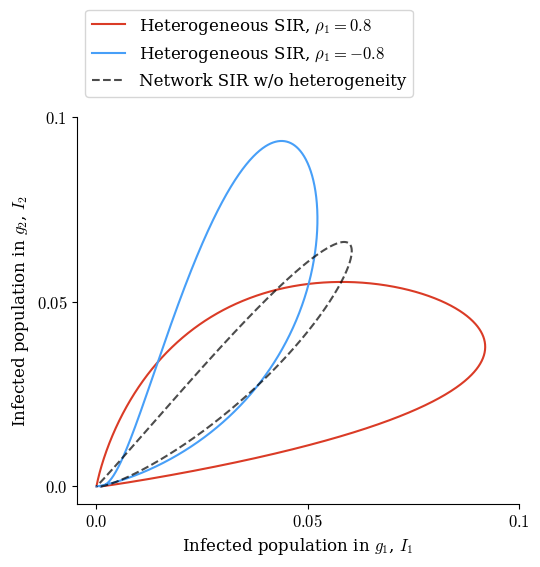

In [2]:
colors = sns.color_palette("blend:#479FF8,#DA3B26", n_colors=5)

k = 10
R0 = 1.5
gam = 0.1

eps = np.linspace(0, 3, 100)
dels = np.linspace(0, 3, 100)

beta = IBC_beta(eps@create_comm(0.8)@dels, eps@create_comm(-0.8)@dels, R0, gam, k, e=0, r=0.5)

P = {'beta': beta, 
     'gamma': gam, 
     'k': k, 
     'e': 0.9, 
     'r': 0.5}

# Initial SIR frequencies
P["S1"] = 1.0 * np.ones((100, 100))
P["I1"] = 0.0 * np.ones((100, 100))
P["R1"] = 0.0 * np.ones((100, 100))
P["S2"] = 1.0 * np.ones((100, 100))
P["I2"] = 0.0 * np.ones((100, 100))
P["R2"] = 0.0 * np.ones((100, 100))

# Seeding comm 1 when positive correlation,
sim1 = P.copy()
sim1["S1"] = 0.999 * np.ones((100, 100))
sim1["I1"] = 0.001 * np.ones((100, 100))
sim1["R1"] = 0.00 * np.ones((100, 100))

# Seeding comm 1 when negative correlation,
sim2 = P.copy()
sim2["S1"] = 0.999 * np.ones((100, 100))
sim2["I1"] = 0.001 * np.ones((100, 100))
sim2["R1"] = 0.00 * np.ones((100, 100))

# Basic SIR model with no heterogeneity
basic_P1 = P.copy()
basic_P1["S1"] = 0.999
basic_P1["I1"] = 0.001 
basic_P1["R1"] = 0.00
basic_P1["S2"] = 1.0
basic_P1["I2"] = 0.00
basic_P1["R2"] = 0.00

basic_P1["beta"] = R0 * gam / k

rep_tmp1 = []
rep_tmp2 = []
rep_tmp_SIR1 = []
for i, rho in enumerate([0.8]):#np.linspace(0, 0.8, 3)):

    # The distributions for the two communities
    sim1["g1"] = create_comm(rho)
    sim1["g2"] = create_comm(-rho)
    sim2["g1"] = create_comm(-rho)
    sim2["g2"] = create_comm(rho)

    results1 = network_model_communities(sim1, 500, 0.1)
    results2 = network_model_communities(sim2, 500, 0.1)
    results_SIR1 = network_SIR_homogeneous(basic_P1, 500, 0.1)

    I1_tmp1 = results1[1]
    I2_tmp1 = results1[4]

    I1_tmp2 = results2[1]
    I2_tmp2 = results2[4]

    I1_SIR_tmp1 = results_SIR1[1]
    I2_SIR_tmp1 = results_SIR1[4]

    rep_tmp1.append((I1_tmp1, I2_tmp1))
    rep_tmp2.append((I1_tmp2, I2_tmp2))

    rep_tmp_SIR1.append((I1_SIR_tmp1, I2_SIR_tmp1))

plt.figure(figsize=(5.5, 6))

plt.plot(rep_tmp1[0][0], rep_tmp1[0][1], label = r'Heterogeneous SIR, $\rho_1 = 0.8$', color = "#DA3B26")
plt.plot(rep_tmp2[0][0], rep_tmp2[0][1], label = r'Heterogeneous SIR, $\rho_1 = -0.8$', color = "#479FF8")
plt.plot(rep_tmp_SIR1[0][0], rep_tmp_SIR1[0][1], label = r'Network SIR w/o heterogeneity', color = 'black', linestyle = '--', alpha = 0.7)

plt.legend(loc="upper left", bbox_to_anchor=(0, 1.3))
plt.xlabel(r"Infected population in $g_1$, $I_1$")
plt.ylabel(r"Infected population in $g_2$, $I_2$")

plt.xticks([0.0, 0.05, 0.1], [r"$0.0$", r"$0.05$", r"$0.1$"])
plt.yticks([0.0, 0.05, 0.1], [r"$0.0$", r"$0.05$", r"$0.1$"])

sns.despine()

plt.tight_layout()

#plt.savefig("Figures/Figure-3.png", dpi = 1000,bbox_inches='tight')
#plt.savefig("Figures/Figure-3.svg", format="svg",bbox_inches='tight')
plt.savefig("Figures/Figure-3.pdf", format="pdf",bbox_inches='tight')
